# <span style="color:blue"> Computer Vision — Spring 2026

## Exercise 3

**Deadline:** June 7, 23:55. \
If you need more time, please send a private Piazza message letting me know that you'll submit late. An extention of up to 1 week is automatically approved.

---



In this exercise, you will practice projection matrices and epipolar geometry related tasks.

## Submission guidelines (Note the change in the submission filename!)

1. Your submission should include the following files only:
   - `hw3_Group_<GROUP_NUMBER>_<ID>_<ID>.ipynb` \
     Replace \<ID\> with your ID number(s). \
     Replace \<GROUP_NUMBER\> with the your moodle group number.
   - All image files used in your experiments.
3. Use Jupyter Notebook.
4. Submit this assignment in pairs (no triplets, singles ok).
   * One student should submit the homework, and the other should not submit anything.
   * If you are not the one submitting, make sure that your collaborator indeed submits!

## Read the following instructions carefully

1. Write **efficient vectorized** code.
2. You are responsible for the correctness of your code and should add as many tests as you see fit.
3. Use `Python 3` and `NumPy 1.3.2` or above. Before submitting the exercise, restart the kernel and run the notebook from start to finish to make sure everything works.
4. You are allowed to use functions and methods from the [Python Standard Library](https://docs.python.org/3/library/) and [NumPy](https://www.numpy.org/devdocs/reference/) only. Any other imports are forbidden unless provided by us.
5. Your code must run without errors. **Code that fails to run will not be graded.**
6. Document your code properly.

## Honor Code
The assignment is a basic tool for learning the material. You can probably find the solution on the web, but then you will not learn anything from it.
You are more than welcome to discuss the assignment with your friends, but you are not allowed to give your code or answers and you are not allowed to use their code or answers.
Feel free to use AI, but you are expected to understand every piece of code that you submit. Please re-read the course's AI policy.
Remember — you take this course in order to learn. Also, the final exam will contain a lot of material from the assignments. 😀

### I declair that I respcet the honor code, and that I understand the course's plagiarism policy and AI policy.
<span style="color:red"> Shay Tanne

In [29]:
import cv2

# This opens an inteactive figure - use it in part B
import matplotlib
matplotlib.use('TkAgg')

import matplotlib.pyplot as plt
import numpy as np
from scipy.linalg import null_space

# This specifies the way plots behave in jupyter notebook
%matplotlib inline
plt.rcParams['figure.figsize'] = (8.0, 8.0) # set default size of plots
plt.rcParams['image.cmap'] = 'gray'


ImportError: Cannot load backend 'TkAgg' which requires the 'tk' interactive framework, as 'headless' is currently running

In [ ]:
import platform
print("Python version: ", platform.python_version())
print("Numpy version: ", np.__version__)
print("OpenCV version: ", cv2.__version__)

Python version:  3.11.15
Numpy version:  2.4.4
OpenCV version:  4.13.0


## <span style="color:blue">Section A: Projection

In this part you will go over projection matrix,  and use them to project 3D points to an image.



## <span style="color:blue">Part A1: Projection Matrix 
Fill the missing values, given partial values of the parameters of the left and right cameras.




**Right image parameters:**
The projection matrix of the right image:

In [ ]:
MR = np.array([[1100.504780,          0,   331.023000,   0],
               [0,          1097.763735,   259.386377,   0],
               [0,                    0,            1,   0]])

The rotation matrix of the right image:

In [ ]:
RR = np.array([[1,0,0],
               [0,1,0],
               [0,0,1]])

The focal length of the right image:

In [ ]:
fR = 1.0

From here on, replace "none" with your answers to the questions. In addition, if there are more than a single possible solution, choose one.
Compute the right image center (principal point):


In [ ]:
OxR = MR[0, 2]
OyR = MR[1, 2]

Compute the right image scale factor which is consistent with MR:

In [ ]:
SxR = MR[0, 0] / fR
SyR = MR[1, 1] / fR

Compute the right image intrinsic matrix which is consistent with MR:

In [ ]:
MintR = MR[:, :3]

 
**Left image parameters**
 
Left image center (principal point):

In [ ]:
OxL = 320.798101 
OyL = 236.431326

Scale factor:

In [ ]:
SxL = 1095.671499
SyL = 1094.559584 

Focal length of the left image: 

In [ ]:
fL = 1

Translation vector w.r.t. the world origin:

In [ ]:
TL = -np.array([[178.2218,18.8171,-13.7744]]).T

Rotation matrix of the left image:

In [ ]:
RL = np.array([[ 0.9891,    0.0602,   -0.1346],
               [-0.0590,    0.9982,    0.0134],
               [0.1351,   -0.0053,    0.9908]])

In [ ]:
vL = RL @ np.array([[0, 0, 1]]).T
vL

array([[-0.1346],
       [ 0.0134],
       [ 0.9908]])

In [ ]:
vR = RR @ np.array([[0, 0, 1]]).T
vR

array([[0],
       [0],
       [1]])

Compute the intrinsic projection matrix of the left camera: 

In [ ]:
MintL = np.array([
    [SxL * fL, 0,        OxL],
    [0,        SyL * fL, OyL],
    [0,        0,        1  ]
]) 

Compute the projection matrix of the left camera

In [ ]:
ML = MintL @ np.hstack((RL, TL))

Compute the COP of the left and the right images, in Cartesian coordinates:   

(You may use the the function *null_space* from *scipy.linalg*) 

In [ ]:
nullspaceL = null_space(ML)
nullspaceR = null_space(MR)

CL = nullspaceL[:3] / nullspaceL[3]
CR = nullspaceR[:3] / nullspaceR[3]
print(f"CL={CL.flatten()} | CR={CR.flatten()}")

CL=[173.29854444  29.59579838 -37.37401658] | CR=[0. 0. 0.]


Compute the distance between CL and CR:
    

In [ ]:
D = float(np.linalg.norm(CL - CR)) 

## <span style="color:blue">Part A2: Hands on Triangulation

Write a function p = proj(M,P) that recieves as input the 3D point P in Euclidean coordinates and a projection matrix M, and outputs the 2D  Euclidean coordinates of the projected point.


In [ ]:
def proj(M: np.ndarray, P: np.ndarray) -> np.ndarray:
    if P.ndim == 1:
        P = P.reshape(-1, 1)
    
    # convert to homogeneous coords [x, y, z, 1]^T
    P_homog = np.vstack((P, np.ones((1, P.shape[1]))))
    
    # project points
    p_homog = M @ P_homog
    
    # convert back to 2d Euclidean coords
    p_eucl = p_homog[:2] / p_homog[2]
    return p_eucl

**<span style="color:blue">Answer Quesion:**\
Given object points in the world coordinate system,  $P=(-140,50,1200)$ and $Q=(30,100,2000)$.

a.	What are the coordinates (Euclidean) of the points in the left camera coordinate system?\
b.	What are the coordinates (Euclidean) of the points in the right camera coordinate system?
    
Note: the camera coordinate system rather than the image coordinate system. (PL means the 3D coordinates in the left **camera** cordinates system, and pL means the 2D coordinates in the left **image** coordinates system.)
   

**<span style="color:blue">Your answer:**

In [ ]:
P = np.array([[-140],[50],[1200]])
Q = np.array([[30],[100],[2000]])

# 3D coords in LEFT camera coord system: P_camera = R * P_world + translation_vector
PL = RL @ P + TL
QL = RL @ Q + TL

# 3D coords in RIGHT camera coord system (RR is I and TR is 0-vector)
PR = P
QR = Q

print(f"a) 3D coords in left camera coord system: \n P = {PL.flatten()} \n Q = {QL.flatten()}\n")
print(f"b) 3D coords in right camera coord system: \n P = {PR.flatten()} \n Q = {QR.flatten()}\n")

a) 3D coords in left camera coord system: 
P = [-475.2058   55.4329 1183.5554] 
Q = [-411.7288  106.0329 1998.8974]
b) 3D coords in right camera coord system: 
P = [-140   50 1200] 
Q = [  30  100 2000]


In [ ]:
# 2D coords in image coord system (projections of 3D points in image plane)
pL = proj(ML,P)
pR = proj(MR,P)
qL = proj(ML,Q)
qR = proj(MR,Q)
print(f" pL = {pL.flatten()} \n pR = {pR.flatten()} \n qL = {qL.flatten()} \n qR = {qR.flatten()}")

 pL = [-119.12169593  287.69602553] 
 pR = [202.63077567 305.12653262] 
 qL = [ 95.11392558 294.49299886] 
 qR = [347.5305717  314.27456375]


### Read two images and display the projections of P and Q on the two given images ###

(<matplotlib.image.AxesImage at 0x7c5d4d3f6a90>,
 Text(0.5, 1.0, 'Right image'),
 <matplotlib.collections.PathCollection at 0x7c5d5e7c6110>)

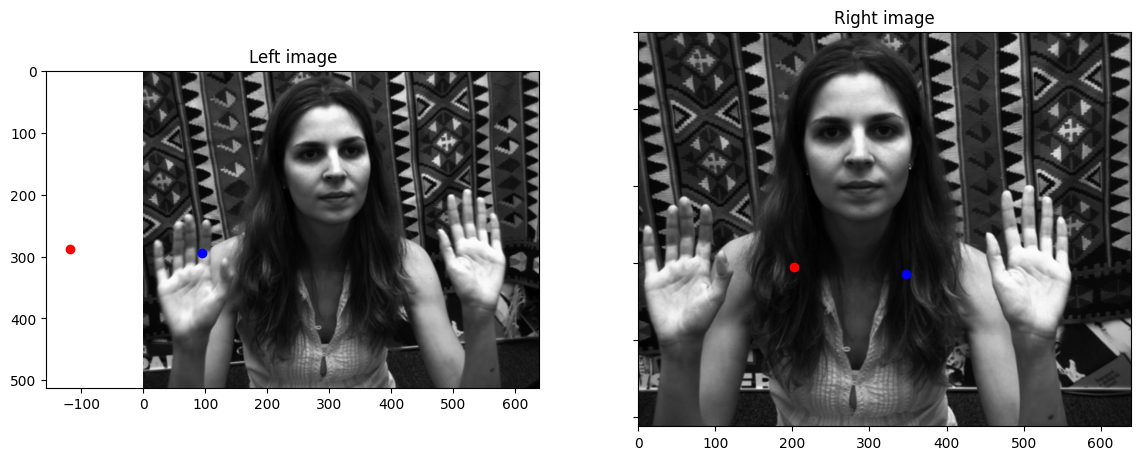

In [ ]:
imL = cv2.imread('left.tif', cv2.IMREAD_GRAYSCALE)
imR = cv2.imread('right.tif', cv2.IMREAD_GRAYSCALE)
    
plt.rcParams['figure.figsize'] = (14.0, 14.0) 
f, ((ax1, ax2)) = plt.subplots(1, 2, sharex='col', sharey='row')

ax1.imshow(imL, cmap='gray'), ax1.set_title('Left image'), ax1.scatter(pL[0], pL[1], color='r'), \
    ax1.scatter(qL[0],qL[1], color = 'b')
ax2.imshow(imR, cmap='gray'), ax2.set_title('Right image'), ax2.scatter(pR[0], pR[1], color = 'r'), \
    ax2.scatter(qR[0],qR[1], color = 'b')

**<span style="color:blue"> Answer Question:**\
Look at the projection of each of the points in the two images. One pair looks as expected, and the other does not. Please give a short explanation of what may have caused it.

**<span style="color:blue">Your answer:**

It seems that in the transition between right camera to left camera, $P$ (red dot) slides left more than $Q$ (blue dot). I believe this is due to parallax:

* the left camera's COP is to the left of that of the right camera
* the direction of the left camera's $z$ axis (where the camera points) is slightly in the positive $x$ direction, whereas the right camera's $z$ axis points straight down the world coordinates' $z$ direction
* in parallax, closer objects undergo greater pixel shift than farther ones
* $P$ is closer to both cameras than $Q$, and so if shifts left significantly more (~27% more)
* in the right image, $P$ and $Q$ seem to live in roughly the same $z$ axis region, and when projected on the left image, $Q$ shifts somewhat reasonably due to the change in COP and camera direction, but $P$ shifts more and over the image boundary, due to parallax effect on its translation

## <span style="color:blue"> Part B: Epipolar Geometry
Compute the fundamental matrix F and the epipoles eL and eR of the left and right images, using their projection matrices.\
Note, you should normalize F by F(3,3) for improved precision.

For the epipoles' computation use the MR and ML and the Center of projections.

**<span style="color:blue">Answer Question:**
Can you double check if they are correct using F? If so, check it.


**<span style="color:blue">Your answer:**\
   Yes, we can doublecheck the epipoles are correct using $F$.\
   Since the epipoles are the null spaces of $F$, multiplying $F$ by them should give the zero vector $\mathbf{0}$ :
   $$Fe_R = \mathbf{0}       ;  F^Te_L = \mathbf{0} $$

The check is done below.

Definitions:
* $K = M_{intrinsic R}$
* translation vector $t_{\times}$ is $t_L$ expressed as matrix multiplication instaed of cross product
* $F = K'^{-T} [t_{\times}] R K^{-1}$

In [ ]:
# lefft epipole - projection of R camera center CR onto L image
eL_homog = ML @ np.vstack((CR, [[1.0]]))
eL = eL_homog / eL_homog[2]

# right epipole - projection of L camera center CL onto R image
eR_homog = MR @ np.vstack((CL, [[1.0]]))
eR = eR_homog / eR_homog[2]

# fundamental matrix F:
K_inv = np.linalg.inv(MintR)            # K^-1
Kprime_inv = np.linalg.inv(MintL)       # (K')^-1
tx = np.array([
    [ 0       , -TL[2, 0],  TL[1, 0]],
    [ TL[2, 0],  0       , -TL[0, 0]],
    [-TL[1, 0],  TL[0, 0],  0       ]
])
F = Kprime_inv.T @ tx @ RL @ K_inv

# normalize
F = F / F[2, 2]


In [ ]:
"""Checking if epipoles are correct using F"""
is_eL_correct = np.allclose(F   @ eR, 0, atol=1e-6)
is_eR_correct = np.allclose(F.T @ eL, 0, atol=1e-6)

print(f"Is eL correct? {is_eL_correct}")
print(f"Is eR correct? {is_eR_correct}")

Is eL correct? True
Is eR correct? True


## Epipolar lines ##

Click on three different points of the **right** image, and check if the epipolar lines on the left image pass through a pixel that corresponds to the one you picked in the right image. Output the set of epipolar lines overlayed on the pair of  images as shown below.

To do so you can use:
1. The code below opens the images in a seperate window. You can click on the right image and  capture the click's coordinates by using the function *plt.ginput*.
2. Take each point (this can be done by a loop) and calculate its epipolar line  on the left image using F.
3. Compute the two endpoints of the line in the image to plot it on the left image. \
    **Hint**: you have linear coefficients - (a,b,c). Calculate the y value in the image for x=0, and x=image.width and plot the result.\
    Use: ax2.plot((x0. xWidth),(yx0, yxWidth))
4. Use the set of the points of the right image that you collected, and draw the epipolar lines on the right image.

In [27]:
# This sould open a new figure window outside of jupyter notebook
%matplotlib qt  

imL = cv2.imread('left.tif', cv2.IMREAD_GRAYSCALE)
imR = cv2.imread('right.tif', cv2.IMREAD_GRAYSCALE)
    
plt.rcParams['figure.figsize'] = (14.0, 14.0) 
f, ((ax1, ax2)) = plt.subplots(1, 2, sharex='col', sharey='row')

ax1.imshow(imL, cmap='gray'), ax1.set_title('Left image')
ax2.imshow(imR, cmap='gray'), ax2.set_title('Right image')

data = plt.ginput(3)

x_val = [x[0] for x in data]
y_val = [x[1] for x in data]

ax2.scatter(x_val, y_val, color='r')

for x in data: 
    # Write your own implementation here.
    pass
    

ImportError: Failed to import any of the following Qt binding modules: PyQt6, PySide6, PyQt5, PySide2

In [ ]:
%matplotlib inline

### This is what you should see:
![Epipolar](epipolarLines1.png "Epipolar Lines example")

##  <span style="color:blue">Part C : SIFT and RANSAC/LMedS</span>

**Follow the matching to compute F.**

Make sure you remember RANSAC, and read a bit about LMedS. Ask yourself: what are the commonalities between the two methods? What are the differences? (Not for submission.)

Go over this epipolar geometry tutorial:
https://docs.opencv.org/master/da/de9/tutorial_py_epipolar_geometry.html 

Below, we find the corresponding featues using the SIFT algorithm and match the closet points. The plotted figure showes the best 300 matches.

❗️Important: SIFT was a patented algorithm and was thus not distributed with vanilla OpenCV. This changed when the patent expired in 2020. If you are getting errors (e.g., missing `cv2.SIFT_create()`) make sure you are using a recent version of OpenCV.

In [ ]:
imL = cv2.imread('left.tif', cv2.IMREAD_GRAYSCALE)
imR = cv2.imread('right.tif', cv2.IMREAD_GRAYSCALE)

# Initiate SIFT detector
sift = cv2.SIFT_create()

# find the keypoints and descriptors with SIFT
kp1, des1 = sift.detectAndCompute(imL, None)
kp2, des2 = sift.detectAndCompute(imR, None)

# FLANN parameters
FLANN_INDEX_KDTREE = 1
index_params = dict(algorithm = FLANN_INDEX_KDTREE, trees = 5)
search_params = dict(checks=50)
# create FlannBasedMatcher object
flann = cv2.FlannBasedMatcher(index_params,search_params)

# Match descriptors.
matches = flann.knnMatch(des1, des2, k=2)

pts1 = []
pts2 = []
matching = []
# Building a list of points screened by ratio test as per Lowe's paper
for i,(m,n) in enumerate(matches):
    if m.distance < 0.8*n.distance:
        pts2.append(kp2[m.trainIdx].pt)
        pts1.append(kp1[m.queryIdx].pt)
        matching.append(m)
        
# Sort them in the order of their distance.
matching = sorted(matching, key = lambda x:x.distance)
        
# Draw first 300 matches.
img3 = np.array([])
img3 = cv2.drawMatches(imL, kp1, imR, kp2, matching[:300], outImg = img3, flags=2)

plt.rcParams['figure.figsize'] = (14.0, 14.0) 
f, ((ax1)) = plt.subplots(1, 1, sharex='col', sharey='row')
ax1.imshow(img3, cmap='gray'), ax1.set_title('Matches')

<span style="color:blue"> Not for submission:</span>

Look at the obtained results.

1. Do you think all matches are correct?
2. In which regions of the scene most of the reliable matches were found?
3. Try the worst 200 mathces as well (`matching[-200:]`).

Now, we will use the found matches to compute **F** using `cv2.findFundamentalMat()`.

In [ ]:
pts1 = np.int32(pts1)
pts2 = np.int32(pts2)

# Computing the F matrix
F_calc, mask = cv2.findFundamentalMat(pts1, pts2, cv2.FM_LMEDS)
# We select only inlier points
pts1 = pts1[mask.ravel()==1]
pts2 = pts2[mask.ravel()==1]

In [ ]:
np.set_printoptions(formatter={'float' : '{:0.7f}'.format})
print(F_calc.T)
print(F)

And now lets check the computed F_calc:
1. Use it to draw the epipolar line as in the example above (change F to F_calc.T)
2. Compute the distance between the computed epipoles by F and by F_calc in each of the images.

You can use `scipy.linalg import null_space`

**<span style="color:blue">Answer Question:**\
    Do you see any differences?
    
**<span style="color:blue">Your answer:**\
    ...

### <span style="color:blue"> Your part in this section :) ###

#### Take two pictures using your own camera and compute the epipolar geometry using LMedS ####

Please submit: 5 corresponding epipolar lines overlayed on   your pair of images.